
Food Image Classification - Regularized SVM Implementation

[1] Loading Datasets
----------------------------------------
Starting dataset loading...
Loading train set: 2184 records
train set loaded: Successfully loaded 2184/2184 images
Loading val set: 468 records
val set loaded: Successfully loaded 468/468 images
Loading test set: 468 records
test set loaded: Successfully loaded 468/468 images

Dataset loading completed: Total 3120 images loaded
Distribution by dataset:
  train: 2184 images
  val: 468 images
  test: 468 images
Distribution by category:
  train set:
    bibimbap: 728 images
    chicken-curry: 728 images
    hamburger: 728 images
  val set:
    bibimbap: 170 images
    chicken-curry: 146 images
    hamburger: 152 images
  test set:
    chicken-curry: 166 images
    hamburger: 160 images
    bibimbap: 142 images

[2] Extracting Features (with data augmentation)
----------------------------------------

Starting HOG feature extraction...

Processing training set (with d

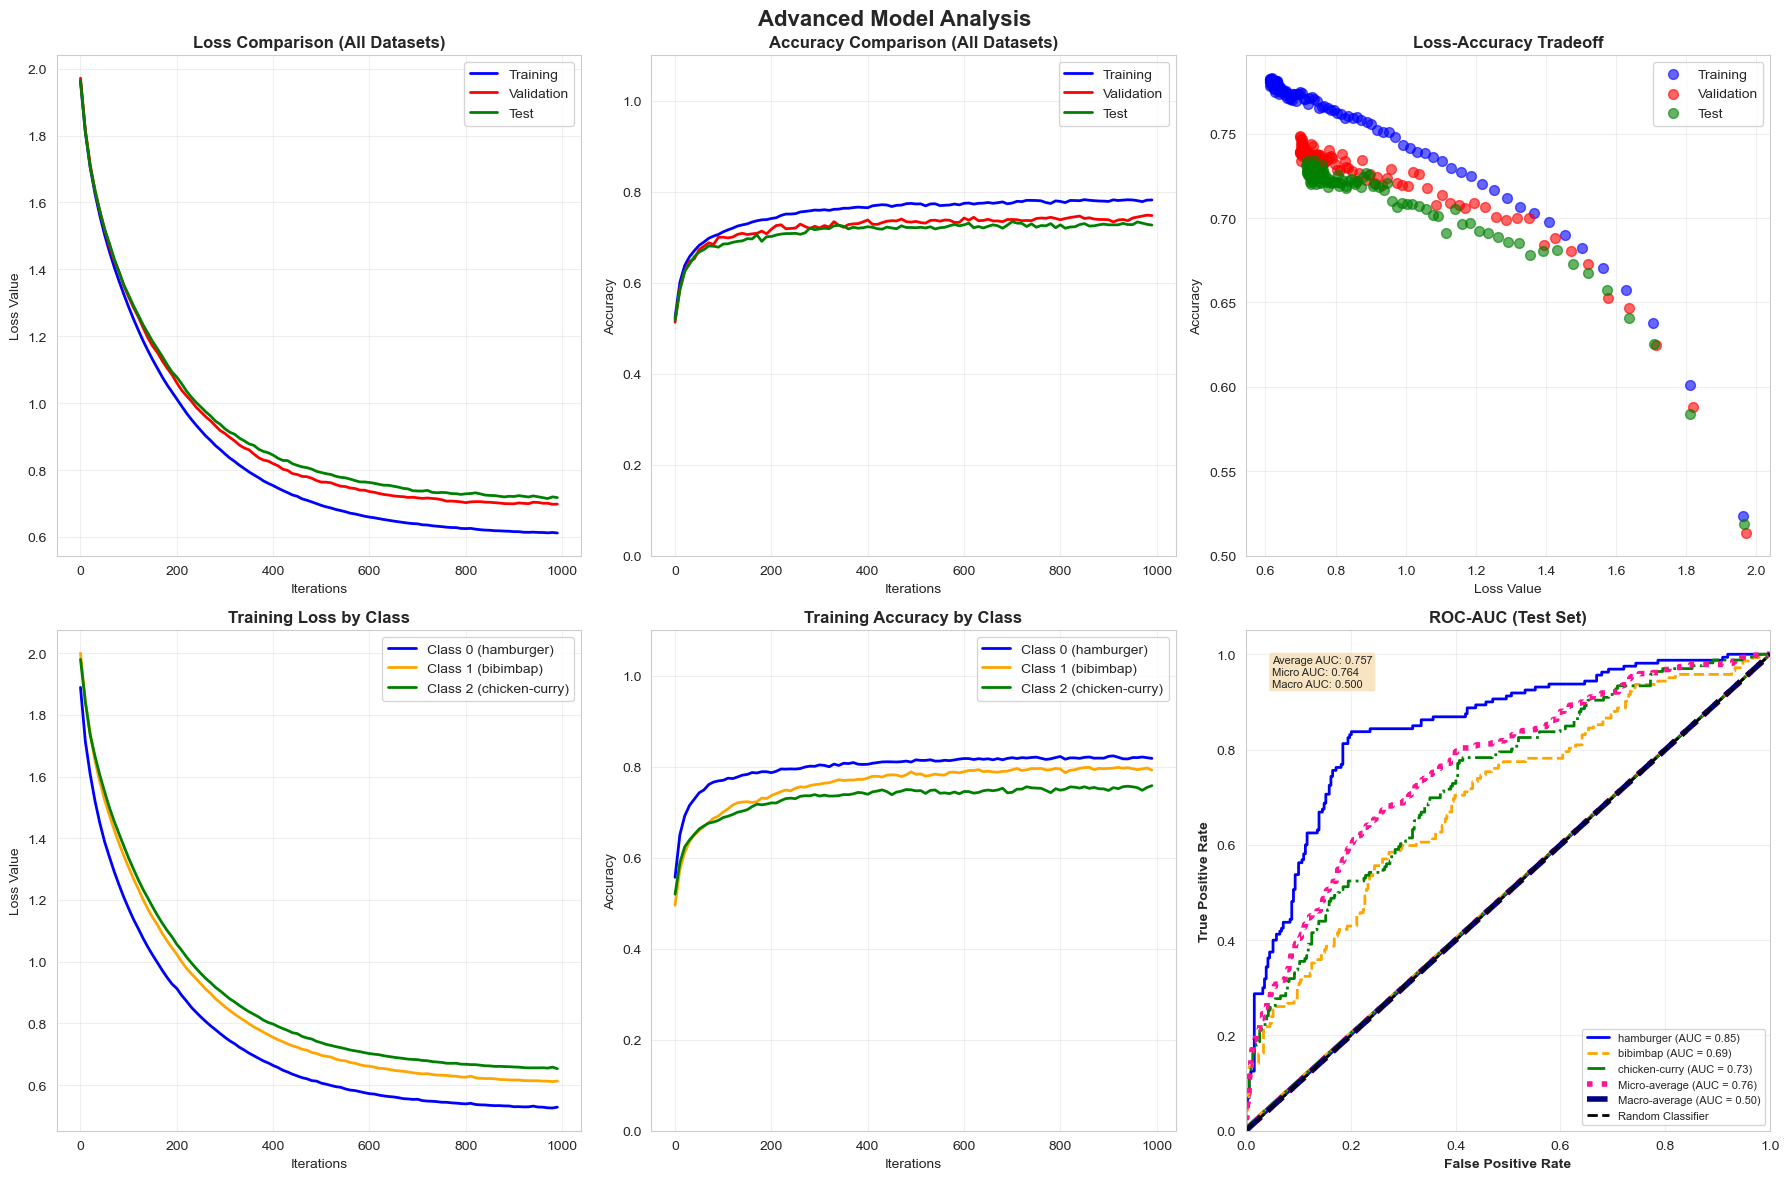

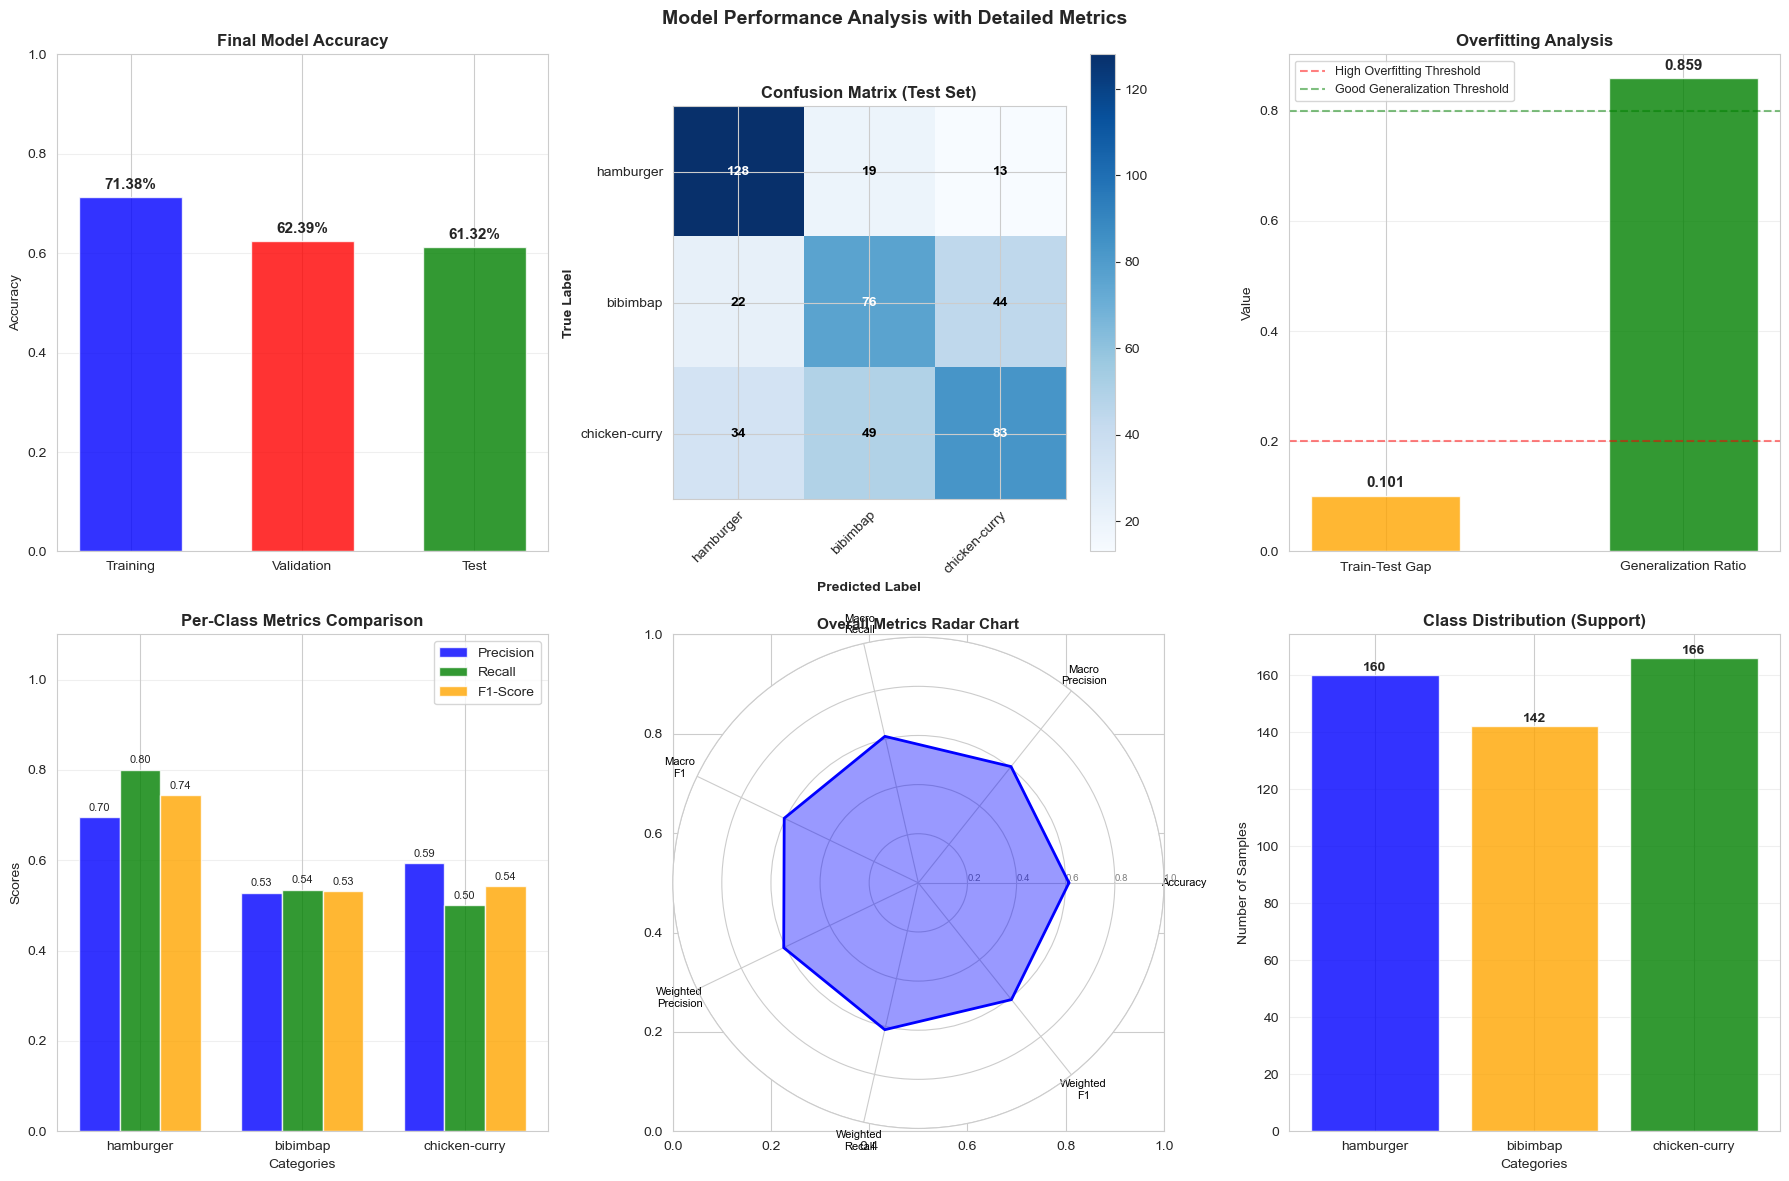


[7] Saving Results and Analysis Report
----------------------------------------

Results saved to: svm_regularized_results

Final Analysis Summary
Training Accuracy:   0.7138 (71.38%)
Validation Accuracy: 0.6239 (62.39%)
Test Accuracy:       0.6132 (61.32%)

Test Set Detailed Metrics:
  Macro F1-Score:     0.6060
  Macro Precision:    0.6054
  Macro Recall:       0.6117
  Weighted F1-Score:  0.6081

Overfitting Analysis:
Train-Test Gap: 0.1006
Moderate Overfitting


In [1]:
import os
import numpy as np
import cv2
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import json
from datetime import datetime


# ==================== 1. CONFIGURATION - TUNED FOR REDUCING OVERFITTING ====================
class Config:
    # Use relative paths
    BASE_DIR = os.getcwd()  # Get the directory where the script is located
    DATA_DIR = os.path.join(BASE_DIR, 'data')

    # CSV file paths (relative to script location)
    TRAIN_CSV = os.path.join(BASE_DIR, 'train_labels.csv')
    VAL_CSV = os.path.join(BASE_DIR, 'val_labels.csv')
    TEST_CSV = os.path.join(BASE_DIR, 'test_labels.csv')

    CATEGORY_KEYWORDS = {
        'hamburger': 0,
        'bibimbap': 1,
        'chicken-curry': 2
    }

    # Image processing parameters
    IMAGE_SIZE = (128, 128)

    # HOG parameters
    HOG_WINDOW_SIZE = (128, 128)
    HOG_BLOCK_SIZE = (16, 16)
    HOG_BLOCK_STRIDE = (8, 8)
    HOG_CELL_SIZE = (8, 8)
    HOG_NBINS = 9

    # SVM parameters - strong regularization to prevent overfitting
    LEARNING_RATE = 0.001
    LAMBDA_PARAM = 1.2
    N_ITERATIONS = 1000

    # Feature scaling
    USE_FEATURE_SCALING = True

    SAVE_FIGURES = True
    RESULTS_DIR = "svm_regularized_results"


# ==================== 2. DATA LOADER ====================
class DataLoader:

    @staticmethod
    def load_csv_dataset(csv_path, dataset_type):
        """Load a single dataset (train/val/test) from CSV file"""
        if not os.path.exists(csv_path):
            print(f"Warning: CSV file {csv_path} does not exist")
            return defaultdict(list), 0

        # Read CSV file
        df = pd.read_csv(csv_path)
        if 'filename' not in df.columns or 'label' not in df.columns:
            print(f"Warning: CSV file {csv_path} missing 'filename' or 'label' column")
            return defaultdict(list), 0

        category_map = Config.CATEGORY_KEYWORDS
        data = defaultdict(list)
        loaded_count = 0

        print(f"Loading {dataset_type} set: {len(df)} records")

        for idx, row in df.iterrows():
            filename = row['filename']
            label = row['label']

            # Validate label validity
            if label not in category_map:
                continue

            # Construct image path
            img_path = os.path.join(Config.DATA_DIR, filename)
            if not os.path.exists(img_path):
                print(f"Warning: Image {img_path} does not exist, skipping")
                continue

            # Read image
            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: Failed to read image {filename}, skipping")
                continue

            # Store by category
            category_id = category_map[label]
            data[category_id].append(img)
            loaded_count += 1

        print(f"{dataset_type} set loaded: Successfully loaded {loaded_count}/{len(df)} images")
        return data, loaded_count

    @staticmethod
    def load_dataset():
        """Load all datasets (train/val/test)"""
        print("Starting dataset loading...")

        # Create data directory if it doesn't exist
        os.makedirs(Config.DATA_DIR, exist_ok=True)

        data_dict = {
            'train': defaultdict(list),
            'val': defaultdict(list),
            'test': defaultdict(list)
        }

        stats = {
            'total_loaded': 0,
            'by_dataset': defaultdict(int),
            'by_category': defaultdict(lambda: defaultdict(int))
        }

        # Load training set
        train_data, train_count = DataLoader.load_csv_dataset(Config.TRAIN_CSV, 'train')
        data_dict['train'] = train_data
        stats['by_dataset']['train'] = train_count

        # Load validation set
        val_data, val_count = DataLoader.load_csv_dataset(Config.VAL_CSV, 'val')
        data_dict['val'] = val_data
        stats['by_dataset']['val'] = val_count

        # Load test set
        test_data, test_count = DataLoader.load_csv_dataset(Config.TEST_CSV, 'test')
        data_dict['test'] = test_data
        stats['by_dataset']['test'] = test_count

        # Calculate total loaded and category-wise statistics
        stats['total_loaded'] = train_count + val_count + test_count
        for dataset_type in ['train', 'val', 'test']:
            for cat_id, images in data_dict[dataset_type].items():
                stats['by_category'][dataset_type][cat_id] = len(images)

        # Category name mapping (id → name)
        category_names = {v: k for k, v in Config.CATEGORY_KEYWORDS.items()}

        # Print loading statistics
        print(f"\nDataset loading completed: Total {stats['total_loaded']} images loaded")
        print("Distribution by dataset:")
        for dataset_type, count in stats['by_dataset'].items():
            print(f"  {dataset_type}: {count} images")
        print("Distribution by category:")
        for dataset_type in ['train', 'val', 'test']:
            print(f"  {dataset_type} set:")
            for cat_id, count in stats['by_category'][dataset_type].items():
                print(f"    {category_names[cat_id]}: {count} images")

        return data_dict, category_names, stats


# ==================== 3. FEATURE EXTRACTION WITH AUGMENTATION ====================
class FeatureExtractor:

    @staticmethod
    def augment_image(image):
        """Simple data augmentation (for training set only)"""
        augmented_images = []

        # Original image
        augmented_images.append(image)

        # Horizontal flip
        augmented_images.append(cv2.flip(image, 1))

        # Brightness adjustment
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        hsv[:, :, 2] = hsv[:, :, 2] * 0.8  # Reduce brightness
        augmented_images.append(cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR))

        return augmented_images

    @staticmethod
    def extract_hog_features(image, augment=False):
        """Extract HOG features with preprocessing"""
        try:
            images_to_process = [image]
            if augment:
                images_to_process = FeatureExtractor.augment_image(image)
            all_features = []
            for img in images_to_process:
                # Resize image
                resized = cv2.resize(img, Config.IMAGE_SIZE)
                # Convert to grayscale
                if len(resized.shape) == 3:
                    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
                else:
                    gray = resized
                # Normalize pixel values
                gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

                # Apply CLAHE for contrast enhancement
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
                gray = clahe.apply(gray)

                # Compute HOG features
                hog = cv2.HOGDescriptor(
                    Config.HOG_WINDOW_SIZE,
                    Config.HOG_BLOCK_SIZE,
                    Config.HOG_BLOCK_STRIDE,
                    Config.HOG_CELL_SIZE,
                    Config.HOG_NBINS
                )

                features = hog.compute(gray)

                if features is not None:
                    all_features.append(features.flatten())

            return all_features if all_features else None

        except Exception as e:
            return None

    @staticmethod
    def extract_features_from_dict(data_dict):
        """Extract features from data dictionary (augment training set, no augmentation for val/test)"""
        print("\nStarting HOG feature extraction...")

        X_train, y_train = [], []
        X_val, y_val = [], []
        X_test, y_test = [], []

        # Process training set (with data augmentation)
        print("\nProcessing training set (with data augmentation)...")
        for cat_id, images in data_dict['train'].items():
            successful = 0

            for img in images:
                features_list = FeatureExtractor.extract_hog_features(img, augment=True)

                if features_list:
                    for features in features_list:
                        X_train.append(features)
                        y_train.append(cat_id)
                    successful += 1

            print(
                f"  Category {cat_id}: {successful}/{len(images)} images (expanded to {successful * 3} samples after augmentation)")

        # Process validation set (no data augmentation)
        print("\nProcessing validation set...")
        for cat_id, images in data_dict['val'].items():
            successful = 0

            for img in images:
                features_list = FeatureExtractor.extract_hog_features(img, augment=False)

                if features_list:
                    X_val.append(features_list[0])
                    y_val.append(cat_id)
                    successful += 1

            print(f"  Category {cat_id}: {successful}/{len(images)} images")

        # Process test set (no data augmentation)
        print("\nProcessing test set...")
        for cat_id, images in data_dict['test'].items():
            successful = 0

            for img in images:
                features_list = FeatureExtractor.extract_hog_features(img, augment=False)

                if features_list:
                    X_test.append(features_list[0])
                    y_test.append(cat_id)
                    successful += 1

            print(f"  Category {cat_id}: {successful}/{len(images)} images")

        # Convert to numpy arrays
        X_train = np.array(X_train) if X_train else np.array([])
        y_train = np.array(y_train) if y_train else np.array([])
        X_val = np.array(X_val) if X_val else np.array([])
        y_val = np.array(y_val) if y_val else np.array([])
        X_test = np.array(X_test) if X_test else np.array([])
        y_test = np.array(y_test) if y_test else np.array([])

        print(f"\nFeature extraction completed:")
        print(f"Training set features: {X_train.shape}")
        print(f"Validation set features: {X_val.shape}")
        print(f"Test set features: {X_test.shape}")

        if len(X_train) > 0:
            print(f"Feature dimension: {X_train.shape[1]}")
            print(f"Note: Training set expanded 3x via data augmentation to improve generalization")

        return X_train, y_train, X_val, y_val, X_test, y_test

    @staticmethod
    def scale_features(X_train, X_val, X_test):
        """Feature scaling (robust scaling to reduce outlier impact)"""
        if not Config.USE_FEATURE_SCALING or len(X_train) == 0:
            return X_train, X_val, X_test

        print("\nPerforming feature scaling...")

        # Robust scaling (based on median and interquartile range)
        median = np.median(X_train, axis=0)
        q75 = np.percentile(X_train, 75, axis=0)
        q25 = np.percentile(X_train, 25, axis=0)
        iqr = q75 - q25

        # Avoid division by zero
        iqr[iqr == 0] = 1

        X_train_scaled = (X_train - median) / iqr
        X_val_scaled = (X_val - median) / iqr if len(X_val) > 0 else X_val
        X_test_scaled = (X_test - median) / iqr if len(X_test) > 0 else X_test

        # Clip extreme values
        X_train_scaled = np.clip(X_train_scaled, -3, 3)
        X_val_scaled = np.clip(X_val_scaled, -3, 3) if len(X_val_scaled) > 0 else X_val_scaled
        X_test_scaled = np.clip(X_test_scaled, -3, 3) if len(X_test_scaled) > 0 else X_test_scaled

        print("Feature scaling completed")

        return X_train_scaled, X_val_scaled, X_test_scaled


# ==================== 4. REGULARIZED SVM IMPLEMENTATION ====================
class RegularizedSVM:

    def __init__(self, learning_rate=0.001, lambda_param=1.2, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.target_class = None  # For one-vs-rest classification

        # Track metrics for all datasets
        self.train_loss_history = []
        self.val_loss_history = []
        self.test_loss_history = []
        self.train_acc_history = []
        self.val_acc_history = []
        self.test_acc_history = []

    def hinge_loss(self, X, y, w, b):
        """Hinge loss with L2 regularization"""
        if len(X) == 0:
            return 0
        distances = 1 - y * (np.dot(X, w) - b)
        distances[distances < 0] = 0
        hinge_loss = np.mean(distances)
        reg_loss = self.lambda_param * np.dot(w, w)
        return hinge_loss + reg_loss

    def compute_accuracy(self, X, y, w, b):
        """Calculate accuracy"""
        if len(X) == 0:
            return 0
        predictions = np.sign(np.dot(X, w) - b)
        return np.mean(predictions == y)

    def fit(self, X_train, y_train, X_val=None, y_val=None, X_test=None, y_test=None, verbose=True):
        """Train SVM while monitoring validation and test sets"""
        n_samples, n_features = X_train.shape

        # Initialize weights (small random values)
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0
        # One-vs-rest classification: convert labels to binary
        y_train_binary = np.where(y_train == self.target_class, 1, -1)
        y_val_binary = np.where(y_val == self.target_class, 1, -1) if y_val is not None else None
        y_test_binary = np.where(y_test == self.target_class, 1, -1) if y_test is not None else None
        print(f"Training SVM for class {self.target_class}...")
        for iteration in range(self.n_iters):
            # Shuffle training data
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train_binary[indices]

            # Mini-batch gradient descent
            batch_size = min(64, n_samples)
            batch_indices = indices[:batch_size]
            X_batch = X_train[batch_indices]
            y_batch = y_train_binary[batch_indices]

            # Calculate distances
            distances = 1 - y_batch * (np.dot(X_batch, self.w) - self.b)

            # Initialize gradients
            dw = 2 * self.lambda_param * self.w  # Regularization gradient
            db = 0

            # Calculate hinge loss gradient for misclassified samples
            misclassified = distances > 0
            if np.any(misclassified):
                dw -= np.sum(y_batch[misclassified, np.newaxis] * X_batch[misclassified], axis=0) / batch_size
                db += np.sum(y_batch[misclassified]) / batch_size

            # Update parameters
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Record metrics every 10 iterations
            if iteration % 10 == 0:
                # Training set metrics
                train_loss = self.hinge_loss(X_train, y_train_binary, self.w, self.b)
                train_acc = self.compute_accuracy(X_train, y_train_binary, self.w, self.b)
                self.train_loss_history.append(train_loss)
                self.train_acc_history.append(train_acc)

                # Validation set metrics
                if X_val is not None and y_val_binary is not None:
                    val_loss = self.hinge_loss(X_val, y_val_binary, self.w, self.b)
                    val_acc = self.compute_accuracy(X_val, y_val_binary, self.w, self.b)
                    self.val_loss_history.append(val_loss)
                    self.val_acc_history.append(val_acc)

                # Test set metrics
                if X_test is not None and y_test_binary is not None:
                    test_loss = self.hinge_loss(X_test, y_test_binary, self.w, self.b)
                    test_acc = self.compute_accuracy(X_test, y_test_binary, self.w, self.b)
                    self.test_loss_history.append(test_loss)
                    self.test_acc_history.append(test_acc)

            # Print information every 100 iterations
            if verbose and iteration % 100 == 0:
                val_info = f", Validation loss: {self.val_loss_history[-1]:.4f}, Validation accuracy: {self.val_acc_history[-1]:.4f}" if len(
                    self.val_loss_history) > 0 else ""
                test_info = f", Test loss: {self.test_loss_history[-1]:.4f}, Test accuracy: {self.test_acc_history[-1]:.4f}" if len(
                    self.test_loss_history) > 0 else ""
                print(f"    Iteration {iteration:4d}/{self.n_iters}, "
                      f"Training loss: {self.train_loss_history[-1]:.4f}, "
                      f"Training accuracy: {self.train_acc_history[-1]:.4f}"
                      f"{val_info}{test_info}")

        print(f"SVM training for class {self.target_class} completed")
        print(f"Final training accuracy: {self.train_acc_history[-1]:.4f}")
        if len(self.val_acc_history) > 0:
            print(f"Final validation accuracy: {self.val_acc_history[-1]:.4f}")
        if len(self.test_acc_history) > 0:
            print(f"Final test accuracy: {self.test_acc_history[-1]:.4f}")

    def predict(self, X):
        """Predict binary labels"""
        if self.w is None:
            raise ValueError("Model not trained")

        return np.sign(np.dot(X, self.w) - self.b)

    def predict_score(self, X):
        """Get raw scores (distance from decision boundary)"""
        return np.dot(X, self.w) - self.b


class RegularizedMulticlassSVM:

    def __init__(self, num_classes, **svm_params):
        self.num_classes = num_classes
        self.svms = []
        self.svm_params = svm_params

        # Store overall metrics for all datasets
        self.overall_train_loss = []
        self.overall_val_loss = []
        self.overall_test_loss = []
        self.overall_train_acc = []
        self.overall_val_acc = []
        self.overall_test_acc = []

    def fit(self, X_train, y_train, X_val=None, y_val=None, X_test=None, y_test=None, verbose=True):
        """Train multiclass SVM using one-vs-rest strategy"""
        print("\nTraining regularized multiclass SVM...")

        self.svms = []

        for class_idx in range(self.num_classes):
            svm = RegularizedSVM(**self.svm_params)
            svm.target_class = class_idx
            svm.fit(X_train, y_train, X_val, y_val, X_test, y_test, verbose=verbose)
            self.svms.append(svm)

            # Average metrics across all classes
            if len(self.overall_train_loss) == 0:
                # Initialize metrics (first class)
                self.overall_train_loss = svm.train_loss_history.copy()
                self.overall_val_loss = svm.val_loss_history.copy()
                self.overall_test_loss = svm.test_loss_history.copy()
                self.overall_train_acc = svm.train_acc_history.copy()
                self.overall_val_acc = svm.val_acc_history.copy()
                self.overall_test_acc = svm.test_acc_history.copy()
            else:
                # Average with previous classes' metrics
                for i in range(len(svm.train_loss_history)):
                    self.overall_train_loss[i] = (self.overall_train_loss[i] + svm.train_loss_history[i]) / 2
                    self.overall_train_acc[i] = (self.overall_train_acc[i] + svm.train_acc_history[i]) / 2

                if len(svm.val_loss_history) > 0:
                    for i in range(len(svm.val_loss_history)):
                        self.overall_val_loss[i] = (self.overall_val_loss[i] + svm.val_loss_history[i]) / 2
                        self.overall_val_acc[i] = (self.overall_val_acc[i] + svm.val_acc_history[i]) / 2

                if len(svm.test_loss_history) > 0:
                    for i in range(len(svm.test_loss_history)):
                        self.overall_test_loss[i] = (self.overall_test_loss[i] + svm.test_loss_history[i]) / 2
                        self.overall_test_acc[i] = (self.overall_test_acc[i] + svm.test_acc_history[i]) / 2

        print("\nAll SVM classifiers trained successfully!")

    def predict(self, X):
        """Multiclass prediction (select class with highest score)"""
        if len(self.svms) == 0:
            raise ValueError("Model not trained")

        if len(X) == 0:
            return np.array([])

        n_samples = X.shape[0]
        scores = np.zeros((n_samples, self.num_classes))

        # Get scores from each classifier
        for class_idx, svm in enumerate(self.svms):
            scores[:, class_idx] = svm.predict_score(X)

        # Return class with highest score
        return np.argmax(scores, axis=1)


# ==================== 5. METRICS CALCULATION FUNCTIONS ====================
class MetricsCalculator:
    """Class to calculate various evaluation metrics"""

    @staticmethod
    def calculate_confusion_matrix(y_true, y_pred, num_classes):
        """Calculate confusion matrix"""
        confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)
        for true, pred in zip(y_true, y_pred):
            confusion_matrix[true][pred] += 1
        return confusion_matrix

    @staticmethod
    def calculate_precision(confusion_matrix, class_idx):
        """Calculate precision for a specific class"""
        tp = confusion_matrix[class_idx, class_idx]
        fp = np.sum(confusion_matrix[:, class_idx]) - tp
        if tp + fp == 0:
            return 0
        return tp / (tp + fp)

    @staticmethod
    def calculate_recall(confusion_matrix, class_idx):
        """Calculate recall for a specific class"""
        tp = confusion_matrix[class_idx, class_idx]
        fn = np.sum(confusion_matrix[class_idx, :]) - tp
        if tp + fn == 0:
            return 0
        return tp / (tp + fn)

    @staticmethod
    def calculate_f1_score(confusion_matrix, class_idx):
        """Calculate F1-score for a specific class"""
        precision = MetricsCalculator.calculate_precision(confusion_matrix, class_idx)
        recall = MetricsCalculator.calculate_recall(confusion_matrix, class_idx)
        if precision + recall == 0:
            return 0
        return 2 * (precision * recall) / (precision + recall)

    @staticmethod
    def calculate_macro_precision(confusion_matrix):
        """Calculate macro-averaged precision"""
        num_classes = confusion_matrix.shape[0]
        precisions = []
        for i in range(num_classes):
            precisions.append(MetricsCalculator.calculate_precision(confusion_matrix, i))
        return np.mean(precisions)

    @staticmethod
    def calculate_macro_recall(confusion_matrix):
        """Calculate macro-averaged recall"""
        num_classes = confusion_matrix.shape[0]
        recalls = []
        for i in range(num_classes):
            recalls.append(MetricsCalculator.calculate_recall(confusion_matrix, i))
        return np.mean(recalls)

    @staticmethod
    def calculate_macro_f1(confusion_matrix):
        """Calculate macro-averaged F1-score"""
        num_classes = confusion_matrix.shape[0]
        f1_scores = []
        for i in range(num_classes):
            f1_scores.append(MetricsCalculator.calculate_f1_score(confusion_matrix, i))
        return np.mean(f1_scores)

    @staticmethod
    def calculate_weighted_precision(confusion_matrix):
        """Calculate weighted precision"""
        num_classes = confusion_matrix.shape[0]
        class_support = np.sum(confusion_matrix, axis=1)
        total_samples = np.sum(class_support)

        weighted_sum = 0
        for i in range(num_classes):
            precision = MetricsCalculator.calculate_precision(confusion_matrix, i)
            weighted_sum += precision * class_support[i]

        return weighted_sum / total_samples if total_samples > 0 else 0

    @staticmethod
    def calculate_weighted_recall(confusion_matrix):
        """Calculate weighted recall"""
        num_classes = confusion_matrix.shape[0]
        class_support = np.sum(confusion_matrix, axis=1)
        total_samples = np.sum(class_support)

        weighted_sum = 0
        for i in range(num_classes):
            recall = MetricsCalculator.calculate_recall(confusion_matrix, i)
            weighted_sum += recall * class_support[i]

        return weighted_sum / total_samples if total_samples > 0 else 0

    @staticmethod
    def calculate_weighted_f1(confusion_matrix):
        """Calculate weighted F1-score"""
        num_classes = confusion_matrix.shape[0]
        class_support = np.sum(confusion_matrix, axis=1)
        total_samples = np.sum(class_support)

        weighted_sum = 0
        for i in range(num_classes):
            f1 = MetricsCalculator.calculate_f1_score(confusion_matrix, i)
            weighted_sum += f1 * class_support[i]

        return weighted_sum / total_samples if total_samples > 0 else 0

    @staticmethod
    def calculate_all_metrics(y_true, y_pred, num_classes):
        """Calculate all metrics and return as dictionary"""
        confusion_matrix = MetricsCalculator.calculate_confusion_matrix(y_true, y_pred, num_classes)

        # Per-class metrics
        per_class_metrics = {}
        for i in range(num_classes):
            per_class_metrics[str(i)] = {
                'precision': float(MetricsCalculator.calculate_precision(confusion_matrix, i)),
                'recall': float(MetricsCalculator.calculate_recall(confusion_matrix, i)),
                'f1_score': float(MetricsCalculator.calculate_f1_score(confusion_matrix, i)),
                'support': int(np.sum(confusion_matrix[i, :]))
            }

        # Overall metrics
        overall_metrics = {
            'accuracy': float(np.mean(y_true == y_pred)),
            'macro_precision': float(MetricsCalculator.calculate_macro_precision(confusion_matrix)),
            'macro_recall': float(MetricsCalculator.calculate_macro_recall(confusion_matrix)),
            'macro_f1': float(MetricsCalculator.calculate_macro_f1(confusion_matrix)),
            'weighted_precision': float(MetricsCalculator.calculate_weighted_precision(confusion_matrix)),
            'weighted_recall': float(MetricsCalculator.calculate_weighted_recall(confusion_matrix)),
            'weighted_f1': float(MetricsCalculator.calculate_weighted_f1(confusion_matrix)),
            'confusion_matrix': confusion_matrix.tolist()  # Convert to list for JSON
        }

        return {
            'per_class': per_class_metrics,
            'overall': overall_metrics
        }

    @staticmethod
    def print_metrics_report(metrics, category_names, dataset_name="Dataset"):
        """Print a comprehensive metrics report"""
        print(f"\n{'=' * 60}")
        print(f"{dataset_name} - Classification Metrics Report")
        print(f"{'=' * 60}")

        # Overall metrics
        overall = metrics['overall']
        print(f"\nOverall Metrics:")
        print(f"  Accuracy:           {overall['accuracy']:.4f} ({overall['accuracy'] * 100:.2f}%)")
        print(f"  Macro Precision:    {overall['macro_precision']:.4f}")
        print(f"  Macro Recall:       {overall['macro_recall']:.4f}")
        print(f"  Macro F1-Score:     {overall['macro_f1']:.4f}")
        print(f"  Weighted Precision: {overall['weighted_precision']:.4f}")
        print(f"  Weighted Recall:    {overall['weighted_recall']:.4f}")
        print(f"  Weighted F1-Score:  {overall['weighted_f1']:.4f}")

        # Per-class metrics
        print(f"\nPer-Class Metrics:")
        print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
        print(f"{'-' * 60}")

        per_class = metrics['per_class']
        for class_idx_str, class_metrics in per_class.items():
            class_idx = int(class_idx_str)
            class_name = category_names.get(class_idx, f"Class {class_idx}")
            print(f"{class_name:<15} {class_metrics['precision']:<12.4f} "
                  f"{class_metrics['recall']:<12.4f} {class_metrics['f1_score']:<12.4f} "
                  f"{class_metrics['support']:<10}")

        print(f"{'=' * 60}")

    @staticmethod
    def convert_to_json_serializable(obj):
        """Convert numpy types to JSON serializable types"""
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, dict):
            return {str(k): MetricsCalculator.convert_to_json_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [MetricsCalculator.convert_to_json_serializable(item) for item in obj]
        else:
            return obj


# ==================== 6. COMPREHENSIVE VISUALIZATION ====================
class ComprehensiveVisualizer:

    @staticmethod
    def plot_advanced_analysis(svm_model, category_names, X_test_scaled=None, y_test=None):
        if len(svm_model.overall_train_loss) == 0:
            print("No training history data to visualize")
            return

        iterations = np.arange(len(svm_model.overall_train_loss)) * 10

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Plot 1: Loss comparison
        ax1 = axes[0, 0]
        ax1.plot(iterations, svm_model.overall_train_loss, 'b-', linewidth=2, label='Training')
        if len(svm_model.overall_val_loss) > 0:
            ax1.plot(iterations[:len(svm_model.overall_val_loss)], svm_model.overall_val_loss,
                     'r-', linewidth=2, label='Validation')
        if len(svm_model.overall_test_loss) > 0:
            ax1.plot(iterations[:len(svm_model.overall_test_loss)], svm_model.overall_test_loss,
                     'g-', linewidth=2, label='Test')
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Loss Value')
        ax1.set_title('Loss Comparison (All Datasets)', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Accuracy comparison
        ax2 = axes[0, 1]
        ax2.plot(iterations, svm_model.overall_train_acc, 'b-', linewidth=2, label='Training')
        if len(svm_model.overall_val_acc) > 0:
            ax2.plot(iterations[:len(svm_model.overall_val_acc)], svm_model.overall_val_acc,
                     'r-', linewidth=2, label='Validation')
        if len(svm_model.overall_test_acc) > 0:
            ax2.plot(iterations[:len(svm_model.overall_test_acc)], svm_model.overall_test_acc,
                     'g-', linewidth=2, label='Test')
        ax2.set_xlabel('Iterations')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Accuracy Comparison (All Datasets)', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim([0, 1.1])

        # Plot 3: Loss-Accuracy tradeoff
        ax3 = axes[0, 2]
        ax3.scatter(svm_model.overall_train_loss, svm_model.overall_train_acc,
                    c='blue', alpha=0.6, s=50, label='Training')
        if len(svm_model.overall_val_loss) > 0 and len(svm_model.overall_val_acc) > 0:
            ax3.scatter(svm_model.overall_val_loss, svm_model.overall_val_acc,
                        c='red', alpha=0.6, s=50, label='Validation')
        if len(svm_model.overall_test_loss) > 0 and len(svm_model.overall_test_acc) > 0:
            ax3.scatter(svm_model.overall_test_loss, svm_model.overall_test_acc,
                        c='green', alpha=0.6, s=50, label='Test')
        ax3.set_xlabel('Loss Value')
        ax3.set_ylabel('Accuracy')
        ax3.set_title('Loss-Accuracy Tradeoff', fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Plot 4: Loss comparison by class
        ax4 = axes[1, 0]
        colors = ['blue', 'orange', 'green']
        for class_idx, svm in enumerate(svm_model.svms):
            iterations_class = np.arange(len(svm.train_loss_history)) * 10
            ax4.plot(iterations_class, svm.train_loss_history,
                     color=colors[class_idx % len(colors)],
                     linewidth=2,
                     label=f'Class {class_idx} ({category_names[class_idx]})')
        ax4.set_xlabel('Iterations')
        ax4.set_ylabel('Loss Value')
        ax4.set_title('Training Loss by Class', fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # Plot 5: Training Accuracy by Class
        ax5 = axes[1, 1]
        colors = ['blue', 'orange', 'green']
        for class_idx, svm in enumerate(svm_model.svms):
            iterations_class = np.arange(len(svm.train_acc_history)) * 10
            ax5.plot(iterations_class, svm.train_acc_history,
                     color=colors[class_idx % len(colors)],
                     linewidth=2,
                     label=f'Class {class_idx} ({category_names[class_idx]})')
        ax5.set_xlabel('Iterations')
        ax5.set_ylabel('Accuracy')
        ax5.set_title('Training Accuracy by Class', fontweight='bold')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
        ax5.set_ylim([0, 1.1])

        # Plot 6: ROC-AUC for Test Set
        ax6 = axes[1, 2]

        if X_test_scaled is not None and y_test is not None and len(X_test_scaled) > 0:
            # Get decision scores for each class
            num_classes = len(category_names)
            scores = np.zeros((len(X_test_scaled), num_classes))

            for class_idx, svm in enumerate(svm_model.svms):
                # Get raw scores (distance from decision boundary)
                scores[:, class_idx] = svm.predict_score(X_test_scaled)

            # Custom label binarize function
            def custom_label_binarize(y, classes):
                """Custom implementation of label binarization"""
                y = np.array(y)
                n_samples = len(y)
                n_classes = len(classes)
                y_bin = np.zeros((n_samples, n_classes), dtype=int)

                for i, cls in enumerate(classes):
                    y_bin[:, i] = (y == cls).astype(int)

                return y_bin

            # Custom ROC curve calculation
            def custom_roc_curve(y_true_bin, y_score):
                """Custom implementation of ROC curve calculation"""
                # Sort by score
                sorted_indices = np.argsort(y_score)[::-1]
                y_true_bin_sorted = y_true_bin[sorted_indices]
                y_score_sorted = y_score[sorted_indices]

                # Get unique thresholds
                thresholds = np.unique(y_score_sorted)
                if len(thresholds) < 2:
                    thresholds = np.array([-np.inf, np.inf])

                # Add extreme thresholds
                thresholds = np.concatenate([[y_score_sorted[0] + 1], thresholds, [y_score_sorted[-1] - 1]])

                # Calculate TPR and FPR at each threshold
                tpr = []
                fpr = []

                for threshold in thresholds:
                    y_pred = (y_score >= threshold).astype(int)

                    # Calculate confusion matrix for binary case
                    tp = np.sum((y_true_bin == 1) & (y_pred == 1))
                    fp = np.sum((y_true_bin == 0) & (y_pred == 1))
                    fn = np.sum((y_true_bin == 1) & (y_pred == 0))
                    tn = np.sum((y_true_bin == 0) & (y_pred == 0))

                    # Calculate TPR and FPR
                    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
                    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0

                    tpr.append(tpr_val)
                    fpr.append(fpr_val)

                return np.array(fpr), np.array(tpr), thresholds

            # Custom AUC calculation using trapezoidal rule
            def custom_auc(fpr, tpr):
                """Calculate AUC using trapezoidal rule"""
                # Sort by FPR
                sorted_indices = np.argsort(fpr)
                fpr_sorted = fpr[sorted_indices]
                tpr_sorted = tpr[sorted_indices]

                # Calculate AUC using trapezoidal rule
                auc_value = 0
                for i in range(1, len(fpr_sorted)):
                    auc_value += (fpr_sorted[i] - fpr_sorted[i - 1]) * (tpr_sorted[i] + tpr_sorted[i - 1]) / 2

                return auc_value

            # Compute ROC curve and AUC for each class
            fpr = dict()
            tpr = dict()
            roc_auc = dict()

            # Binarize the output for one-vs-rest ROC using custom function
            y_test_bin = custom_label_binarize(y_test, classes=range(num_classes))

            # Compute ROC curve and ROC area for each class
            for i in range(num_classes):
                fpr[i], tpr[i], _ = custom_roc_curve(y_test_bin[:, i], scores[:, i])
                roc_auc[i] = custom_auc(fpr[i], tpr[i])

            # Compute micro-average ROC curve and ROC area
            # Flatten predictions and scores for micro-average
            y_test_bin_flat = y_test_bin.ravel()
            scores_flat = scores.ravel()

            fpr["micro"], tpr["micro"], _ = custom_roc_curve(y_test_bin_flat, scores_flat)
            roc_auc["micro"] = custom_auc(fpr["micro"], tpr["micro"])

            # Compute macro-average ROC curve and ROC area
            # First aggregate all false positive rates
            all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))

            # Then interpolate all ROC curves at these points
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(num_classes):
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

            # Finally average it and compute AUC
            mean_tpr /= num_classes
            fpr["macro"] = all_fpr
            tpr["macro"] = mean_tpr
            roc_auc["macro"] = custom_auc(fpr["macro"], tpr["macro"])

            # Plot ROC curves
            colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
            line_styles = ['-', '--', '-.', ':']

            # Plot each class ROC curve
            for i, color in zip(range(num_classes), colors):
                ax6.plot(fpr[i], tpr[i], color=color, lw=2,
                         label=f'{category_names[i]} (AUC = {roc_auc[i]:.2f})',
                         linestyle=line_styles[i % len(line_styles)])

            # Plot micro-average ROC curve
            ax6.plot(fpr["micro"], tpr["micro"],
                     color='deeppink', linestyle=':', linewidth=4,
                     label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')

            # Plot macro-average ROC curve
            ax6.plot(fpr["macro"], tpr["macro"],
                     color='navy', linestyle='--', linewidth=4,
                     label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})')

            # Plot diagonal line (random classifier)
            ax6.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

            ax6.set_xlim([0.0, 1.0])
            ax6.set_ylim([0.0, 1.05])
            ax6.set_xlabel('False Positive Rate', fontweight='bold')
            ax6.set_ylabel('True Positive Rate', fontweight='bold')
            ax6.set_title('ROC-AUC (Test Set)', fontweight='bold')
            ax6.legend(loc="lower right", fontsize=8)
            ax6.grid(True, alpha=0.3)

            # Add text box with summary statistics
            avg_auc = np.mean([roc_auc[i] for i in range(num_classes)])
            textstr = f'Average AUC: {avg_auc:.3f}\nMicro AUC: {roc_auc["micro"]:.3f}\nMacro AUC: {roc_auc["macro"]:.3f}'
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            ax6.text(0.05, 0.95, textstr, transform=ax6.transAxes, fontsize=8,
                     verticalalignment='top', bbox=props)
        else:
            # Fallback to original bar chart if no test data available
            if hasattr(svm_model.svms[0], 'train_acc_history') and len(svm_model.svms[0].train_acc_history) > 0:
                final_train_acc = svm_model.overall_train_acc[-1]
                final_val_acc = svm_model.overall_val_acc[-1] if len(svm_model.overall_val_acc) > 0 else 0
                final_test_acc = svm_model.overall_test_acc[-1] if len(svm_model.overall_test_acc) > 0 else 0

                metrics = ['Training', 'Validation', 'Test']
                values = [final_train_acc, final_val_acc, final_test_acc]
                colors_bar = ['blue', 'red', 'green']

                bars = ax6.bar(metrics, values, color=colors_bar, alpha=0.8, width=0.5)
                ax6.set_ylabel('Accuracy')
                ax6.set_title('Final Model Performance', fontweight='bold')
                ax6.set_ylim([0, 1])
                ax6.grid(True, alpha=0.3, axis='y')

                for bar, val in zip(bars, values):
                    height = bar.get_height()
                    ax6.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                             f'{val:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        plt.suptitle('Advanced Model Analysis', fontsize=16, fontweight='bold')
        plt.tight_layout()

        if Config.SAVE_FIGURES:
            plt.savefig(os.path.join(Config.RESULTS_DIR, 'advanced_analysis.png'),
                        dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_final_performance(train_acc, val_acc, test_acc, confusion_matrix, category_names, metrics_dict=None):
        """Final performance visualization (accuracy, confusion matrix, overfitting analysis)"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Plot 1: Accuracy comparison
        ax1 = axes[0, 0]
        datasets = ['Training', 'Validation', 'Test']
        accuracies = [train_acc, val_acc, test_acc]
        colors = ['blue', 'red', 'green']

        bars = ax1.bar(datasets, accuracies, color=colors, alpha=0.8, width=0.6)
        ax1.set_ylabel('Accuracy')
        ax1.set_title('Final Model Accuracy', fontweight='bold')
        ax1.set_ylim([0, 1])
        ax1.grid(True, alpha=0.3, axis='y')

        for bar, acc in zip(bars, accuracies):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                     f'{acc:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        # Plot 2: Confusion matrix
        ax2 = axes[0, 1]
        im = ax2.imshow(confusion_matrix, cmap='Blues', interpolation='nearest')

        ax2.set_xticks(np.arange(len(category_names)))
        ax2.set_yticks(np.arange(len(category_names)))
        ax2.set_xticklabels([category_names[i] for i in range(len(category_names))])
        ax2.set_yticklabels([category_names[i] for i in range(len(category_names))])

        plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        for i in range(len(category_names)):
            for j in range(len(category_names)):
                text = ax2.text(j, i, confusion_matrix[i, j],
                                ha="center", va="center",
                                color="white" if confusion_matrix[i, j] > confusion_matrix.max() / 2 else "black",
                                fontweight='bold')

        ax2.set_xlabel('Predicted Label', fontweight='bold')
        ax2.set_ylabel('True Label', fontweight='bold')
        ax2.set_title(f'Confusion Matrix (Test Set)', fontweight='bold')

        plt.colorbar(im, ax=ax2)

        # Plot 3: Overfitting analysis
        ax3 = axes[0, 2]
        overfitting_gap = train_acc - test_acc
        generalization_ratio = test_acc / train_acc if train_acc > 0 else 0

        metrics = ['Train-Test Gap', 'Generalization Ratio']
        values = [overfitting_gap, generalization_ratio]
        colors_metrics = ['red' if overfitting_gap > 0.2 else 'orange',
                          'green' if generalization_ratio > 0.8 else 'orange']

        bars2 = ax3.bar(metrics, values, color=colors_metrics, alpha=0.8, width=0.5)
        ax3.set_ylabel('Value')
        ax3.set_title('Overfitting Analysis', fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')

        # Reference lines
        ax3.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='High Overfitting Threshold')
        ax3.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good Generalization Threshold')

        for bar, val in zip(bars2, values):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax3.legend(fontsize=9)

        # Plot 4: Precision, Recall, F1-Score Comparison
        ax4 = axes[1, 0]
        if metrics_dict is not None:
            categories = list(category_names.values())
            # Convert string keys to int for indexing
            precision_scores = [metrics_dict['per_class'][str(i)]['precision'] for i in range(len(categories))]
            recall_scores = [metrics_dict['per_class'][str(i)]['recall'] for i in range(len(categories))]
            f1_scores = [metrics_dict['per_class'][str(i)]['f1_score'] for i in range(len(categories))]

            x = np.arange(len(categories))
            width = 0.25

            bars1 = ax4.bar(x - width, precision_scores, width, label='Precision', color='blue', alpha=0.8)
            bars2 = ax4.bar(x, recall_scores, width, label='Recall', color='green', alpha=0.8)
            bars3 = ax4.bar(x + width, f1_scores, width, label='F1-Score', color='orange', alpha=0.8)

            ax4.set_xlabel('Categories')
            ax4.set_ylabel('Scores')
            ax4.set_title('Per-Class Metrics Comparison', fontweight='bold')
            ax4.set_xticks(x)
            ax4.set_xticklabels(categories)
            ax4.legend()
            ax4.set_ylim([0, 1.1])
            ax4.grid(True, alpha=0.3, axis='y')

            # Add value labels
            for bars in [bars1, bars2, bars3]:
                for bar in bars:
                    height = bar.get_height()
                    ax4.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                             f'{height:.2f}', ha='center', va='bottom', fontsize=8)

        # Plot 5: Overall Metrics Radar Chart
        ax5 = axes[1, 1]
        if metrics_dict is not None:
            overall = metrics_dict['overall']
            metrics_names = ['Accuracy', 'Macro\nPrecision', 'Macro\nRecall', 'Macro\nF1',
                             'Weighted\nPrecision', 'Weighted\nRecall', 'Weighted\nF1']
            metrics_values = [
                overall['accuracy'],
                overall['macro_precision'],
                overall['macro_recall'],
                overall['macro_f1'],
                overall['weighted_precision'],
                overall['weighted_recall'],
                overall['weighted_f1']
            ]

            # Number of variables
            N = len(metrics_names)

            # What will be the angle of each axis in the plot
            angles = [n / float(N) * 2 * np.pi for n in range(N)]
            angles += angles[:1]

            # Initialise the spider plot
            ax5 = plt.subplot(2, 3, 5, polar=True)

            # Draw one axe per variable + add labels
            plt.xticks(angles[:-1], metrics_names, color='black', size=8)

            # Draw ylabels
            ax5.set_rlabel_position(0)
            plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=7)
            plt.ylim(0, 1)

            # Plot data
            values = metrics_values + [metrics_values[0]]
            ax5.plot(angles, values, linewidth=2, linestyle='solid', color='blue')
            ax5.fill(angles, values, 'b', alpha=0.4)

            ax5.set_title('Overall Metrics Radar Chart', fontweight='bold', size=11)

        # Plot 6: Per-Class Support Distribution
        ax6 = axes[1, 2]
        if metrics_dict is not None:
            categories = list(category_names.values())
            support_counts = [metrics_dict['per_class'][str(i)]['support'] for i in range(len(categories))]

            bars = ax6.bar(categories, support_counts, color=['blue', 'orange', 'green'], alpha=0.8)
            ax6.set_xlabel('Categories')
            ax6.set_ylabel('Number of Samples')
            ax6.set_title('Class Distribution (Support)', fontweight='bold')
            ax6.grid(True, alpha=0.3, axis='y')

            # Add value labels
            for bar in bars:
                height = bar.get_height()
                ax6.text(bar.get_x() + bar.get_width() / 2., height + 0.5,
                         f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        plt.suptitle('Model Performance Analysis with Detailed Metrics', fontsize=14, fontweight='bold')
        plt.tight_layout()

        if Config.SAVE_FIGURES:
            plt.savefig(os.path.join(Config.RESULTS_DIR, 'final_performance.png'),
                        dpi=300, bbox_inches='tight')
        plt.show()


# ==================== 7. MAIN PIPELINE ====================
def main():
    print("\n" + "=" * 80)
    print("Food Image Classification - Regularized SVM Implementation")
    print("=" * 80)

    # Create results directory
    os.makedirs(Config.RESULTS_DIR, exist_ok=True)

    try:
        # Step 1: Load datasets (from CSV files)
        print("\n[1] Loading Datasets")
        print("-" * 40)
        data_dict, category_names, stats = DataLoader.load_dataset()

        if data_dict is None or stats['total_loaded'] == 0:
            print("Error: Failed to load any data")
            return

        # Step 2: Extract features (with data augmentation for training set)
        print("\n[2] Extracting Features (with data augmentation)")
        print("-" * 40)
        X_train, y_train, X_val, y_val, X_test, y_test = \
            FeatureExtractor.extract_features_from_dict(data_dict)

        if len(X_train) == 0:
            print("Error: Failed to extract training features")
            return

        # Step 3: Feature scaling
        print("\n[3] Scaling Features")
        print("-" * 40)
        X_train_scaled, X_val_scaled, X_test_scaled = \
            FeatureExtractor.scale_features(X_train, X_val, X_test)

        # Step 4: Train regularized SVM model
        print("\n[4] Training Regularized SVM Model")
        print("-" * 40)
        print(f"Parameters: lambda={Config.LAMBDA_PARAM} (strong regularization)")
        print(f"Learning rate: {Config.LEARNING_RATE}")
        print(f"Number of iterations: {Config.N_ITERATIONS}")

        model = RegularizedMulticlassSVM(
            num_classes=len(category_names),
            learning_rate=Config.LEARNING_RATE,
            lambda_param=Config.LAMBDA_PARAM,
            n_iters=Config.N_ITERATIONS
        )

        model.fit(X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, verbose=True)

        # Step 5: Final evaluation with comprehensive metrics
        print("\n[5] Performing Final Evaluation with Detailed Metrics")
        print("-" * 40)

        results = {}
        all_metrics = {}

        # Evaluate training set
        train_pred = model.predict(X_train_scaled)
        train_acc = np.mean(train_pred == y_train)
        train_metrics = MetricsCalculator.calculate_all_metrics(y_train, train_pred, len(category_names))
        results['train'] = {
            'accuracy': train_acc,
            'predictions': train_pred,
            'true_labels': y_train,
            'metrics': train_metrics
        }
        print(f"\nTraining Set Metrics:")
        MetricsCalculator.print_metrics_report(train_metrics, category_names, "Training Set")

        # Evaluate validation set
        if len(X_val_scaled) > 0:
            val_pred = model.predict(X_val_scaled)
            val_acc = np.mean(val_pred == y_val)
            val_metrics = MetricsCalculator.calculate_all_metrics(y_val, val_pred, len(category_names))
            results['val'] = {
                'accuracy': val_acc,
                'predictions': val_pred,
                'true_labels': y_val,
                'metrics': val_metrics
            }
            print(f"\nValidation Set Metrics:")
            MetricsCalculator.print_metrics_report(val_metrics, category_names, "Validation Set")

        # Evaluate test set
        if len(X_test_scaled) > 0:
            test_pred = model.predict(X_test_scaled)
            test_acc = np.mean(test_pred == y_test)
            test_metrics = MetricsCalculator.calculate_all_metrics(y_test, test_pred, len(category_names))

            # Calculate confusion matrix for visualization
            num_classes = len(category_names)
            confusion_matrix = MetricsCalculator.calculate_confusion_matrix(y_test, test_pred, num_classes)

            results['test'] = {
                'accuracy': test_acc,
                'predictions': test_pred,
                'true_labels': y_test,
                'metrics': test_metrics,
                'confusion_matrix': confusion_matrix
            }
            print(f"\nTest Set Metrics:")
            MetricsCalculator.print_metrics_report(test_metrics, category_names, "Test Set")

        # Step 6: Generate visualization results
        print("\n[6] Generating Visualization Results")
        print("-" * 40)

        ComprehensiveVisualizer.plot_advanced_analysis(model, category_names, X_test_scaled, y_test)

        if 'test' in results:
            ComprehensiveVisualizer.plot_final_performance(
                train_acc,
                val_acc if 'val' in results else 0,
                test_acc,
                results['test']['confusion_matrix'],
                category_names,
                test_metrics  # Pass metrics for enhanced visualization
            )

        # Step 7: Save results and analysis report
        print("\n[7] Saving Results and Analysis Report")
        print("-" * 40)

        # Prepare metrics for JSON serialization
        serializable_metrics = {}
        for dataset_type in ['train', 'val', 'test']:
            if dataset_type in results:
                metrics = results[dataset_type]['metrics']
                # Convert to JSON serializable format
                serializable_metrics[dataset_type] = MetricsCalculator.convert_to_json_serializable(metrics)

        # Save final report - ensure all numpy types are converted
        final_report = {
            'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'Parameter Settings': {
                'Learning Rate': float(Config.LEARNING_RATE),
                'Regularization Parameter': float(Config.LAMBDA_PARAM),
                'Number of Iterations': int(Config.N_ITERATIONS),
                'Feature Scaling': Config.USE_FEATURE_SCALING,
                'Data Augmentation': '3x (flip + brightness adjustment)'
            },
            'Final Results': {
                'Training Accuracy': float(train_acc),
                'Validation Accuracy': float(val_acc) if 'val' in results else 0.0,
                'Test Accuracy': float(test_acc) if 'test' in results else 0.0,
                'Overfitting Gap': float(train_acc - test_acc) if 'test' in results else 0.0,
                'Generalization Ratio': float(test_acc / train_acc) if train_acc > 0 and 'test' in results else 0.0
            },
            'Detailed Metrics': serializable_metrics,
            'Training History': {
                'Training Loss': [float(x) for x in model.overall_train_loss],
                'Validation Loss': [float(x) for x in model.overall_val_loss] if len(
                    model.overall_val_loss) > 0 else [],
                'Test Loss': [float(x) for x in model.overall_test_loss] if len(model.overall_test_loss) > 0 else [],
                'Training Accuracy': [float(x) for x in model.overall_train_acc],
                'Validation Accuracy': [float(x) for x in model.overall_val_acc] if len(
                    model.overall_val_acc) > 0 else [],
                'Test Accuracy': [float(x) for x in model.overall_test_acc] if len(model.overall_test_acc) > 0 else []
            },
            'Dataset Information': {
                'Training Set Samples': int(len(X_train_scaled)),
                'Validation Set Samples': int(len(X_val_scaled)),
                'Test Set Samples': int(len(X_test_scaled)),
                'Feature Dimension': int(X_train_scaled.shape[1]) if len(X_train_scaled) > 0 else 0,
                'Original Images Loaded': int(stats['total_loaded'])
            }
        }

        with open(os.path.join(Config.RESULTS_DIR, 'final_analysis.json'), 'w', encoding='utf-8') as f:
            json.dump(final_report, f, indent=4, ensure_ascii=False)

        print(f"\nResults saved to: {Config.RESULTS_DIR}")

        # Final analysis summary
        print("\n" + "=" * 80)
        print("Final Analysis Summary")
        print("=" * 80)
        print(f"Training Accuracy:   {train_acc:.4f} ({train_acc * 100:.2f}%)")
        if 'val' in results:
            print(f"Validation Accuracy: {val_acc:.4f} ({val_acc * 100:.2f}%)")
        if 'test' in results:
            print(f"Test Accuracy:       {test_acc:.4f} ({test_acc * 100:.2f}%)")

        if 'test' in results:
            test_metrics_overall = results['test']['metrics']['overall']
            print(f"\nTest Set Detailed Metrics:")
            print(f"  Macro F1-Score:     {test_metrics_overall['macro_f1']:.4f}")
            print(f"  Macro Precision:    {test_metrics_overall['macro_precision']:.4f}")
            print(f"  Macro Recall:       {test_metrics_overall['macro_recall']:.4f}")
            print(f"  Weighted F1-Score:  {test_metrics_overall['weighted_f1']:.4f}")

            gap = train_acc - test_acc
            print(f"\nOverfitting Analysis:")
            print(f"Train-Test Gap: {gap:.4f}")
            if gap > 0.2:
                print(f"Severe Overfitting - Recommend increasing regularization parameter")
            elif gap > 0.1:
                print(f"Moderate Overfitting")
            else:
                print(f"Good Generalization Ability")

        print("=" * 80)

    except Exception as e:
        print(f"\nMain pipeline error: {str(e)}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()